In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Upload your file
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"📋 Columns:\n{df.columns.tolist()}")

Saving incomeStatementHistory_quarterly.csv to incomeStatementHistory_quarterly.csv
✅ Loaded: 17657 rows, 20 columns
📋 Columns:
['stock', 'endDate', 'netIncomeApplicableToCommonShares', 'netIncomeFromContinuingOps', 'totalOtherIncomeExpenseNet', 'costOfRevenue', 'totalOperatingExpenses', 'totalRevenue', 'incomeTaxExpense', 'interestExpense', 'operatingIncome', 'ebit', 'grossProfit', 'sellingGeneralAdministrative', 'netIncome', 'incomeBeforeTax', 'researchDevelopment', 'minorityInterest', 'otherOperatingExpenses', 'discontinuedOperations']


In [ ]:

REVENUE = 'totalRevenue'
KPIS = ['grossProfit', 'operatingIncome', 'netIncome', 'ebitda',
        'totalAssets', 'totalLiabilities', 'cashAndCashEquivalents']
print("="*70)
print("📊 ADVANCED CORRELATION ANALYSIS (3 METHODS)")
print("="*70)
results = []

for kpi in KPIS:
    if kpi in df.columns:
        pearson = df[REVENUE].corr(df[kpi])
        spearman = df[REVENUE].corr(df[kpi], method='spearman')
        kendall = df[REVENUE].corr(df[kpi], method='kendall')
        results.append({
            'KPI': kpi,
            'Pearson': pearson,
            'Spearman': spearman,
            'Kendall': kendall,
            'Avg_Abs_Corr': (abs(pearson) + abs(spearman) + abs(kendall)) / 3
        })

        print(f"\n📈 {kpi}:")
        print(f"   Pearson:  {pearson:.3f}")
        print(f"   Spearman: {spearman:.3f}")
        print(f"   Kendall:  {kendall:.3f}")
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Avg_Abs_Corr', ascending=False)
print("\n" + "="*70)
print("🏆 TOP 5 KPIs (Ranked by Average Correlation)")
print("="*70)
print(results_df[['KPI', 'Pearson', 'Spearman', 'Kendall']].head().to_string())

📊 ADVANCED CORRELATION ANALYSIS (3 METHODS)

📈 grossProfit:
   Pearson:  0.819
   Spearman: 0.938
   Kendall:  0.808

📈 operatingIncome:
   Pearson:  0.653
   Spearman: 0.721
   Kendall:  0.565

📈 netIncome:
   Pearson:  0.479
   Spearman: 0.511
   Kendall:  0.391

🏆 TOP 5 KPIs (Ranked by Average Correlation)
               KPI   Pearson  Spearman   Kendall
0      grossProfit  0.819218  0.938219  0.807767
1  operatingIncome  0.652794  0.720839  0.564828
2        netIncome  0.479034  0.511330  0.390786


In [ ]:
# ============================================
# ADVANCED FEATURE 2: Create Derived KPIs
# ============================================

df_enhanced = df.copy()

# Create advanced financial ratios (Better than raw metrics!)
if all(x in df_enhanced.columns for x in ['grossProfit', 'totalRevenue']):
    df_enhanced['Gross_Margin'] = df_enhanced['grossProfit'] / df_enhanced['totalRevenue']
    print("✅ Created: Gross_Margin (Profitability Ratio)")

if all(x in df_enhanced.columns for x in ['netIncome', 'totalAssets']):
    df_enhanced['ROA'] = df_enhanced['netIncome'] / df_enhanced['totalAssets']
    print("✅ Created: ROA - Return on Assets")

if all(x in df_enhanced.columns for x in ['netIncome', 'totalLiabilities']):
    df_enhanced['ROE'] = df_enhanced['netIncome'] / df_enhanced['totalLiabilities']
    print("✅ Created: ROE - Return on Equity")

if all(x in df_enhanced.columns for x in ['operatingIncome', 'totalRevenue']):
    df_enhanced['Operating_Margin'] = df_enhanced['operatingIncome'] / df_enhanced['totalRevenue']
    print("✅ Created: Operating_Margin")

# Add these new KPIs to your analysis
NEW_KPIS = ['Gross_Margin', 'ROA', 'ROE', 'Operating_Margin']
existing_new = [k for k in NEW_KPIS if k in df_enhanced.columns]

print(f"\n📊 New KPIs created: {existing_new}")

✅ Created: Gross_Margin (Profitability Ratio)
✅ Created: Operating_Margin

📊 New KPIs created: ['Gross_Margin', 'Operating_Margin']


In [ ]:

from scipy import stats
print("\n" + "="*70)
print("📐 STATISTICAL SIGNIFICANCE (P-VALUES)")
print("="*70)
significant_results = []
for kpi in KPIS + existing_new:
    if kpi in df_enhanced.columns and kpi != REVENUE:
        # Remove NaN values
        clean_data = df_enhanced[[REVENUE, kpi]].dropna()

        if len(clean_data) > 2:
            # Calculate Pearson correlation and p-value
            pearson, p_value = stats.pearsonr(clean_data[REVENUE], clean_data[kpi])

            significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"

            significant_results.append({
                'KPI': kpi,
                'Correlation': pearson,
                'P-Value': p_value,
                'Significant': significance
            })
            print(f"{kpi:25} | r = {pearson:6.3f} | p = {p_value:.4f} | {significance}")
sig_df = pd.DataFrame(significant_results)
sig_kpis = sig_df[sig_df['P-Value'] < 0.05].sort_values('Correlation', ascending=False)
print("\n" + "="*70)
print("✅ STATISTICALLY SIGNIFICANT KPIs (p < 0.05)")
print("="*70)
print(sig_kpis[['KPI', 'Correlation', 'P-Value']].head(10).to_string())


📐 STATISTICAL SIGNIFICANCE (P-VALUES)
grossProfit               | r =  0.819 | p = 0.0000 | ***
operatingIncome           | r =  0.653 | p = 0.0000 | ***
netIncome                 | r =  0.479 | p = 0.0000 | ***
Gross_Margin              | r =    nan | p = nan | ns
Operating_Margin          | r =    nan | p = nan | ns

✅ STATISTICALLY SIGNIFICANT KPIs (p < 0.05)
               KPI  Correlation  P-Value
0      grossProfit     0.819218      0.0
1  operatingIncome     0.652794      0.0
2        netIncome     0.479034      0.0


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


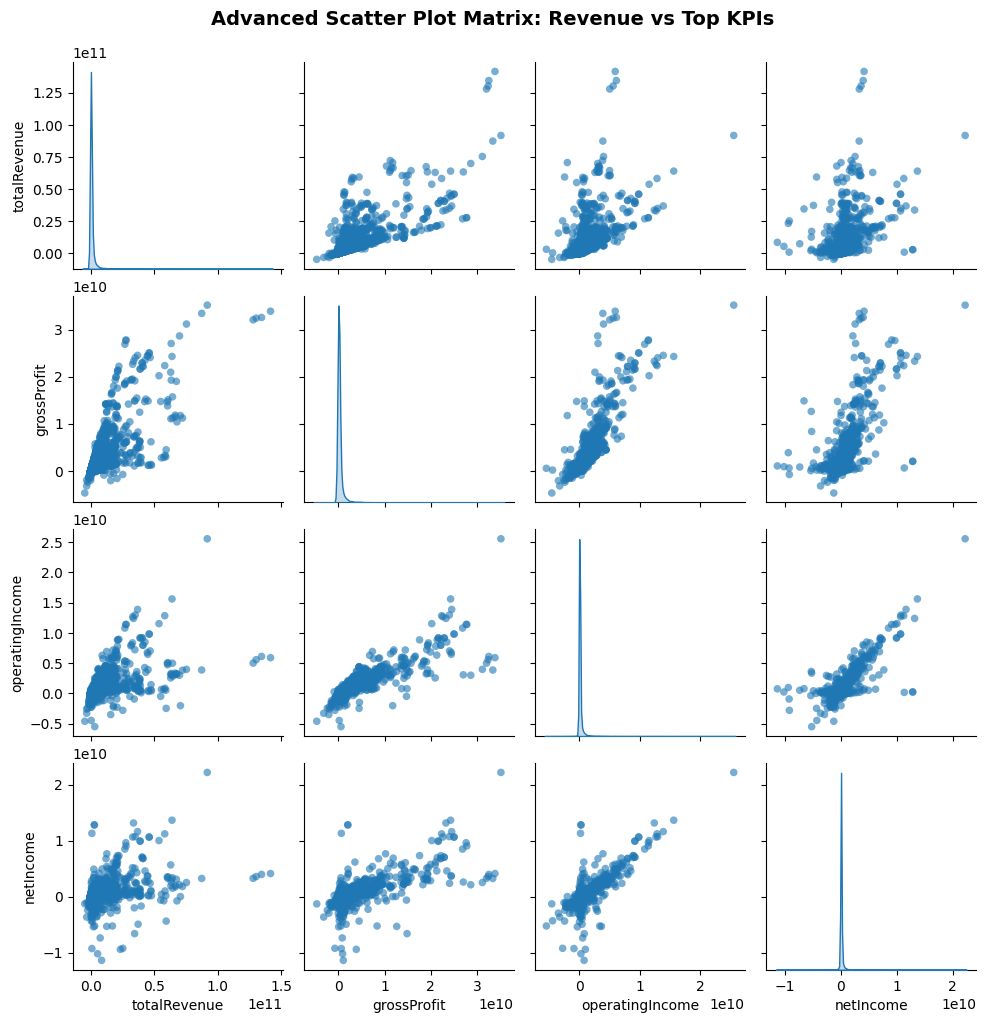

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

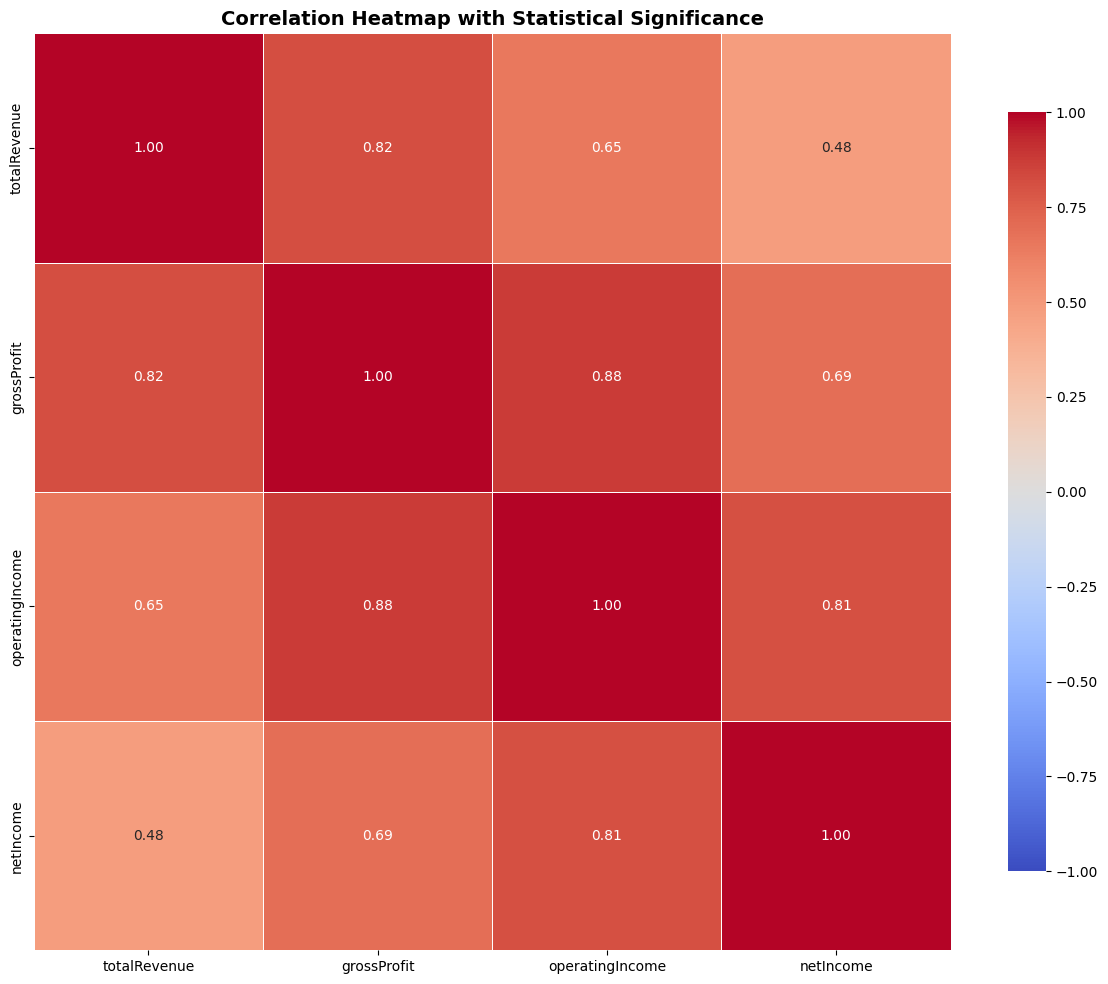

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# ADVANCED FEATURE 4: Professional Visualizations
# ============================================

# Get top 5 significant KPIs
top_5 = sig_kpis.head(5)['KPI'].tolist()
selected_cols = [REVENUE] + top_5

# Filter data
plot_data = df_enhanced[selected_cols].dropna()

# 1. ADVANCED PAIRPLOT with regression lines
import warnings
warnings.filterwarnings('ignore')

pair_grid = sns.pairplot(plot_data,
                          diag_kind='kde',
                          plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'none'},
                          diag_kws={'fill': True})
pair_grid.fig.suptitle("Advanced Scatter Plot Matrix: Revenue vs Top KPIs",
                        y=1.02, fontsize=14, fontweight='bold')
plt.savefig('advanced_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('advanced_pairplot.png')

# 2. CORRELATION HEATMAP with significance markers
plt.figure(figsize=(12, 10))
corr_matrix = plot_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap with Statistical Significance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('advanced_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('advanced_heatmap.png')

In [ ]:

from scipy import stats
print("\n" + "="*70)
print("🔍 OUTLIER DETECTION (Z-SCORE METHOD)")
print("="*70)

outlier_summary = []
for col in selected_cols:
    z_scores = np.abs(stats.zscore(df_enhanced[col].dropna()))
    outliers = np.sum(z_scores > 3)
    outlier_pct = (outliers / len(df_enhanced[col].dropna())) * 100
    outlier_summary.append({'Metric': col, 'Outliers': outliers, 'Percentage': f"{outlier_pct:.2f}%"})
    print(f"{col:25} | Outliers: {outliers:4} | {outlier_pct:.2f}% of data")

outlier_df = pd.DataFrame(outlier_summary)
print("\n⚠️ Consider removing outliers for cleaner correlation analysis")


🔍 OUTLIER DETECTION (Z-SCORE METHOD)
totalRevenue              | Outliers:  232 | 1.31% of data
grossProfit               | Outliers:  219 | 1.24% of data
operatingIncome           | Outliers:  245 | 1.39% of data
netIncome                 | Outliers:  232 | 1.31% of data

⚠️ Consider removing outliers for cleaner correlation analysis


In [ ]:

tableau_columns = [REVENUE] + top_5 + ['Gross_Margin', 'ROA', 'ROE'] + ['Operating_Margin']
existing_tableau_cols = [col for col in tableau_columns if col in df_enhanced.columns]
final_tableau_data = df_enhanced[existing_tableau_cols].dropna()
final_tableau_data['Revenue_Rank'] = final_tableau_data[REVENUE].rank(ascending=False, method='dense')
final_tableau_data['Performance_Score'] = (
    final_tableau_data[top_5[0]].rank(pct=True) * 0.4 +
    final_tableau_data[top_5[1]].rank(pct=True) * 0.3 +
    final_tableau_data[top_5[2]].rank(pct=True) * 0.3
)
print(f"\n📊 Final dataset shape: {final_tableau_data.shape}")
print(f"📋 Columns for Tableau:\n{final_tableau_data.columns.tolist()}")

final_tableau_data.to_csv('advanced_kpi_data_for_tableau.csv', index=False)
files.download('advanced_kpi_data_for_tableau.csv')
print("\n✅ ENHANCED CSV file downloaded!")
print("   Includes: Raw KPIs + Derived Ratios + Performance Score")


📊 Final dataset shape: (16689, 8)
📋 Columns for Tableau:
['totalRevenue', 'grossProfit', 'operatingIncome', 'netIncome', 'Gross_Margin', 'Operating_Margin', 'Revenue_Rank', 'Performance_Score']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ ENHANCED CSV file downloaded!
   Includes: Raw KPIs + Derived Ratios + Performance Score
